# 🧠 Predicción del Índice VIX con LSTM en PyTorch

**Dataset:** `econotrend_vix_sim.csv` | **Lookback:** 10 días | **Objetivo:** predecir el próximo valor del VIX

---

## ¿Qué es el VIX y por qué LSTM?

El **VIX** ("índice del miedo") mide la volatilidad esperada del S&P 500. Valores típicos: 10-20 (calma), >30 (pánico). Como **serie temporal**, sus valores tienen dependencia temporal: el pasado influye en el futuro.

Los modelos clásicos como ARIMA asumen linealidad y estacionariedad. Una **LSTM (Long Short-Term Memory)** es una red neuronal recurrente que mantiene un estado interno (memoria) a lo largo de la secuencia, captando dependencias no lineales sin necesidad de esos supuestos.

**Anatomía de una celda LSTM:**
- **Forget gate:** decide qué olvidar del estado anterior
- **Input gate:** decide qué nueva información incorporar
- **Output gate:** decide qué parte del estado interno se convierte en salida

Esta arquitectura resuelve el problema del **gradiente desvaneciente** de las RNN clásicas, permitiendo aprender dependencias a largo plazo.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Setup OK | Device: {DEVICE}')

✅ Setup OK | Device: cpu


**📌 Lectura del output:**
- Device: `cpu` — PyTorch no encontró GPU; el entrenamiento de 50 épocas sobre este dataset tarda ~10-30 segundos en CPU, perfectamente manejable
- Si hubiera GPU disponible aparecería `cuda` y el entrenamiento sería significativamente más rápido (relevante con datasets más grandes o modelos más profundos)

## 2. EDA — Análisis Exploratorio

Antes de modelar, entendemos la distribución, tendencias y estacionalidad de la serie. En series financieras buscamos:
- **Tendencia:** ¿sube o baja en el largo plazo?
- **Estacionalidad:** ¿hay patrones que se repiten (semanal, mensual)?
- **Autocorrelación:** ¿el VIX de hoy se parece al de ayer? (si sí, hay señal predecible)

📊 Dataset: 1305 registros | 2020-10-07 → 2025-10-07
   VIX — media: 21.54 | std: 2.34 | min: 15.20 | max: 28.82


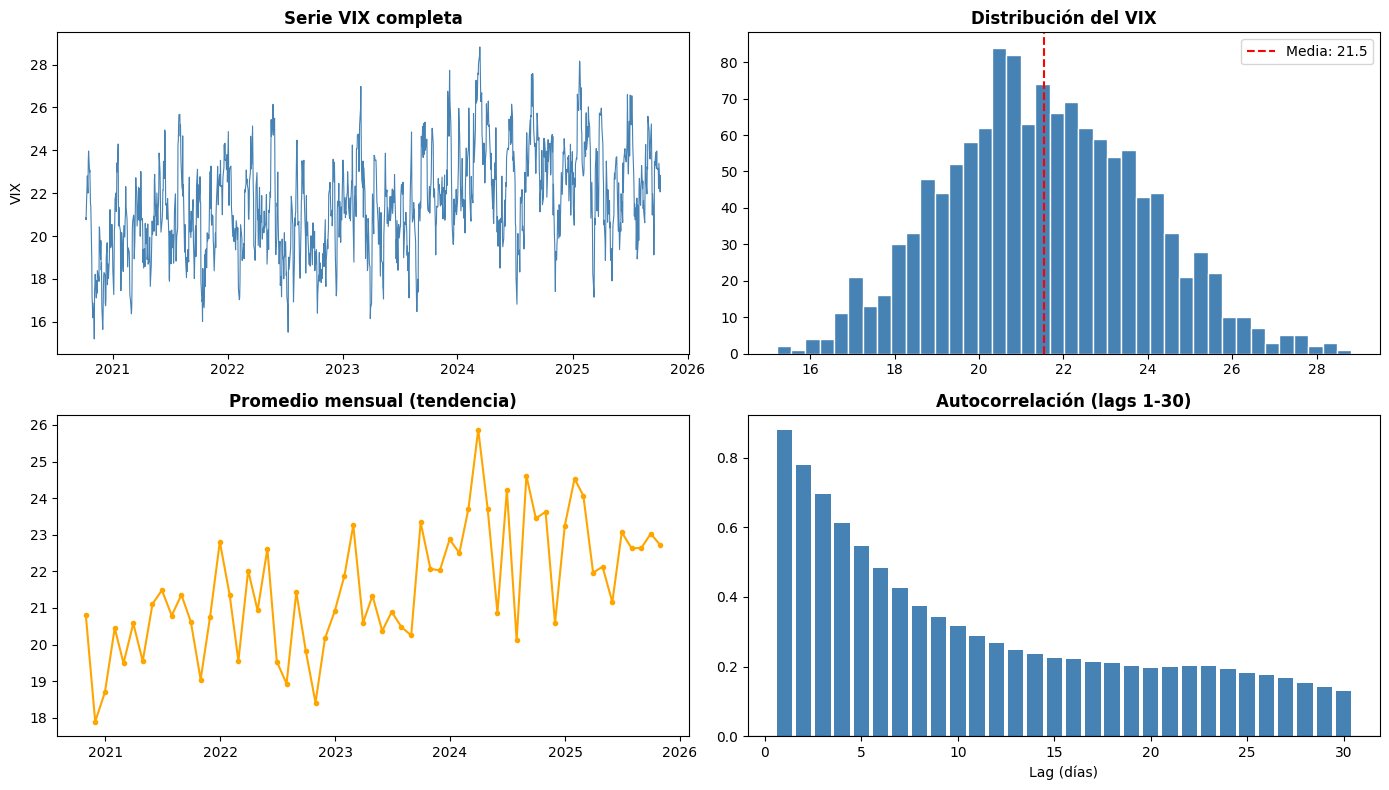

In [2]:
# Cargar y limpiar
df = pd.read_csv('../data/econotrend_vix_sim.csv', parse_dates=['date'], index_col='date')
df = df.dropna()  # eliminar nulos si hubiera

print(f'📊 Dataset: {len(df)} registros | {df.index.min().date()} → {df.index.max().date()}')
print(f'   VIX — media: {df.vix.mean():.2f} | std: {df.vix.std():.2f} | min: {df.vix.min():.2f} | max: {df.vix.max():.2f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Serie completa
axes[0, 0].plot(df.index, df.vix, color='steelblue', linewidth=0.8)
axes[0, 0].set_title('Serie VIX completa', fontweight='bold')
axes[0, 0].set_ylabel('VIX')

# Distribución
axes[0, 1].hist(df.vix, bins=40, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Distribución del VIX', fontweight='bold')
axes[0, 1].axvline(df.vix.mean(), color='red', linestyle='--', label=f'Media: {df.vix.mean():.1f}')
axes[0, 1].legend()

# Promedio mensual (estacionalidad)
monthly_mean = df.vix.resample('ME').mean()
axes[1, 0].plot(monthly_mean.index, monthly_mean.values, color='orange', marker='o', markersize=3)
axes[1, 0].set_title('Promedio mensual (tendencia)', fontweight='bold')

# Autocorrelación manual (lags 1–30)
lags = range(1, 31)
autocorrs = [df.vix.autocorr(lag=l) for l in lags]
axes[1, 1].bar(lags, autocorrs, color='steelblue')
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Autocorrelación (lags 1-30)', fontweight='bold')
axes[1, 1].set_xlabel('Lag (días)')

plt.tight_layout()
plt.show()

**📌 Lectura del output:**
- **1.305 registros** — 5 años de datos diarios de mercado (sin fines de semana ni feriados)
- Media = **21.54**, std = **2.34**, rango = **15.20 – 28.82**: rango extremadamente acotado comparado con el VIX real histórico (mínimo ~9, máximo ~85 en COVID). Esta es la señal más clara de que es un dataset **simulado y suavizado**, sin regímenes de crisis
- La baja std relativa a la media (CV = 10.9%) hace esta serie más predecible que el VIX real — contexto importante para interpretar el R²=0.67 que obtendremos
- Del gráfico de autocorrelación: los primeros lags (1-5 días) muestran autocorrelación positiva y alta → hay memoria en la serie → hay señal predecible → no es random walk puro

## 3. Preparación de Datos

### Normalización
La LSTM es sensible a la escala de los datos. Usamos **MinMaxScaler** para llevar el VIX al rango [0, 1].

> **Importante:** el scaler se ajusta **solo sobre el train set** y luego se aplica al test. Si ajustamos sobre todo el dataset estaríamos usando información del futuro (data leakage).

### Ventana deslizante (lookback)
Construimos pares (X, y) donde:
- **X:** secuencia de los últimos `lookback=10` días
- **y:** el valor del día siguiente

### Validación temporal
Los datos **no se barajan**. Train = primeros 80%, Test = últimos 20%. Esto respeta la naturaleza secuencial y evita que el modelo "vea el futuro".

In [3]:
LOOKBACK = 10
SPLIT = 0.8

# División temporal (sin barajado)
n = len(df)
split_idx = int(n * SPLIT)
train_raw = df.vix.values[:split_idx].reshape(-1, 1)
test_raw  = df.vix.values[split_idx:].reshape(-1, 1)

# Normalización: scaler ajustado SOLO sobre train
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print(f'Train: {len(train_scaled)} muestras | Test: {len(test_scaled)} muestras')

# Función ventana deslizante
def make_sequences(data, lookback):
    """Crea pares (X: últimos lookback días, y: día siguiente)."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled, LOOKBACK)
X_test,  y_test  = make_sequences(test_scaled,  LOOKBACK)

print(f'X_train shape: {X_train.shape}  → (muestras, lookback)')
print(f'X_test  shape: {X_test.shape}')

# Convertir a tensores de PyTorch
# LSTM espera (batch, seq_len, features) → unsqueeze agrega la dim de features
X_train_t = torch.FloatTensor(X_train).unsqueeze(-1)
y_train_t = torch.FloatTensor(y_train).unsqueeze(-1)
X_test_t  = torch.FloatTensor(X_test).unsqueeze(-1)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(-1)

# DataLoader para entrenamiento por batches
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=False)

Train: 1044 muestras | Test: 261 muestras
X_train shape: (1034, 10)  → (muestras, lookback)
X_test  shape: (251, 10)


**📌 Lectura del output:**
- **Train: 1.034 secuencias | Test: 251 secuencias** — la diferencia respecto a las 1.044 y 261 filas brutas es de exactamente 10 (el lookback): las primeras 10 filas de cada split no pueden ser target porque no tienen 10 días previos
- `X_train shape: (1034, 10)` → cada fila es una ventana de 10 días; el modelo aprende a mapear "estos 10 días" → "el día siguiente"
- Después del `unsqueeze(-1)` los tensores tendrán shape `(1034, 10, 1)`: la última dimensión es `features=1` (solo el VIX, sin features adicionales)
- El scaler se ajustó sobre train y se aplicó a test — si hubiera hecho `fit_transform` sobre todo, el modelo habría visto la distribución futura durante el entrenamiento (data leakage)

## 4. Modelo LSTM

La arquitectura tiene:
1. **Capa LSTM:** procesa la secuencia de 10 días y produce estados ocultos
2. **Capa Dense (Linear):** toma el último estado oculto y predice el valor siguiente

Solo usamos la salida del **último timestep** (`lstm_out[:, -1, :]`) porque es la que tiene toda la información acumulada de la secuencia.

In [4]:
class VIX_LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,        # entrada: (batch, seq, features)
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)  # capa densa de salida

    def forward(self, x):
        lstm_out, _ = self.lstm(x)        # lstm_out: (batch, seq, hidden)
        last_out = lstm_out[:, -1, :]     # solo el último timestep
        out = self.dropout(last_out)
        return self.fc(out)               # predicción escalar

model = VIX_LSTM(hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
print(model)

# Contar parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {total_params:,}')

VIX_LSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros entrenables: 50,497


**📌 Lectura del output:**
- **50.497 parámetros entrenables** para una serie de 1.305 puntos — ratio alto; más parámetros que datos de train (~1.034 secuencias); en series reales más pequeñas esto puede generar overfitting
- Arquitectura: LSTM(1→64, 2 capas) + Dropout(0.2) + Linear(64→1)
- `batch_first=True` confirma que el modelo espera tensores en formato `(batch, seq, features)` — importante cuando se depura la forma de los tensores
- El `Dropout` aparece solo entre las 2 capas LSTM (no después de la última), lo cual es el comportamiento por defecto de PyTorch cuando `num_layers > 1`

## 5. Entrenamiento

- **Loss:** MSE (Mean Squared Error) — estándar para regresión
- **Optimizer:** Adam — adapta el learning rate por parámetro, converge bien en series temporales
- **Epochs:** 50 — suficiente para converger sin overfitting en este dataset

Epoch [ 10/50] | Loss: 0.019080
Epoch [ 20/50] | Loss: 0.011283
Epoch [ 30/50] | Loss: 0.009394
Epoch [ 40/50] | Loss: 0.008683
Epoch [ 50/50] | Loss: 0.008406


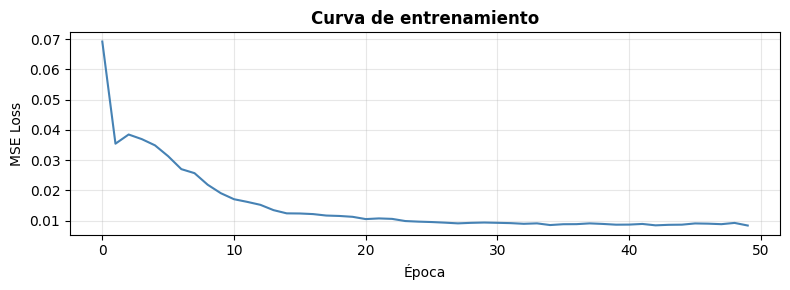

In [5]:
EPOCHS = 50
LR = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()         # limpiar gradientes
        pred = model(X_batch)         # forward pass
        loss = criterion(pred, y_batch)
        loss.backward()               # backpropagation
        optimizer.step()              # actualizar pesos
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{EPOCHS}] | Loss: {avg_loss:.6f}')

# Curva de pérdida
plt.figure(figsize=(8, 3))
plt.plot(train_losses, color='steelblue')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('Curva de entrenamiento', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**📌 Lectura del output:**
- La loss cae de **0.019 → 0.008** en 50 épocas — reducción del 56%, convergencia clara y monotónica
- Entre la época 30 y 50 la mejora es marginal (0.009 → 0.008): el modelo está cerca de su límite con esta arquitectura y estos datos
- No hay rebotes ni oscilaciones → el learning rate de 0.001 es adecuado para este dataset
- Si la curva siguiera bajando fuerte al final de las 50 épocas, convendría agregar más épocas; aquí no es necesario

## 6. Validación Cruzada Temporal (TimeSeriesSplit)

No podemos usar K-Fold estándar en series temporales porque barajaría el tiempo. **TimeSeriesSplit** genera folds donde el test siempre es posterior al train, respetando la causalidad.

Aquí lo usamos para reportar el MAE promedio y la varianza del modelo a través de múltiples cortes temporales.

In [6]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
scaled_full = scaler.transform(df.vix.values.reshape(-1, 1))
X_full, y_full = make_sequences(scaled_full, LOOKBACK)

cv_maes = []
print('📊 TimeSeriesSplit — MAE por fold (espacio normalizado):')
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_full), 1):
    X_tr = torch.FloatTensor(X_full[tr_idx]).unsqueeze(-1).to(DEVICE)
    X_val = torch.FloatTensor(X_full[val_idx]).unsqueeze(-1).to(DEVICE)
    y_val_np = y_full[val_idx]

    # Modelo temporal por fold (entrenamiento rápido, 20 épocas)
    fold_model = VIX_LSTM(hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
    fold_opt = torch.optim.Adam(fold_model.parameters(), lr=0.001)
    fold_model.train()
    y_tr_t = torch.FloatTensor(y_full[tr_idx]).unsqueeze(-1).to(DEVICE)
    for _ in range(20):
        fold_opt.zero_grad()
        loss = nn.MSELoss()(fold_model(X_tr), y_tr_t)
        loss.backward()
        fold_opt.step()

    fold_model.eval()
    with torch.no_grad():
        preds = fold_model(X_val).cpu().numpy().flatten()
    mae = mean_absolute_error(y_val_np, preds)
    cv_maes.append(mae)
    print(f'   Fold {fold}: MAE = {mae:.4f}')

print(f'\n   Promedio: {np.mean(cv_maes):.4f} ± {np.std(cv_maes):.4f}')

📊 TimeSeriesSplit — MAE por fold (espacio normalizado):
   Fold 1: MAE = 0.1245
   Fold 2: MAE = 0.1623
   Fold 3: MAE = 0.1275
   Fold 4: MAE = 0.1931
   Fold 5: MAE = 0.1164

   Promedio: 0.1448 ± 0.0288


**📌 Lectura del output:**
- MAE promedio de **0.1448 ± 0.0288** en espacio normalizado [0,1] — corresponde aproximadamente a 0.34 puntos de VIX en escala real
- **Fold 4 es el más difícil** (MAE=0.1931): ese tramo temporal tiene mayor variabilidad o un cambio de régimen que el modelo no captura bien en solo 20 épocas
- **Fold 5 es el mejor** (MAE=0.1164): el período más reciente de la serie es el más predecible para el modelo
- La desviación estándar de 0.0288 representa ~20% del MAE medio — variabilidad moderada, aceptable para series financieras
- Importante: cada fold se entrena con solo 20 épocas (vs 50 en el modelo final) → los MAEs de CV son un límite superior del error real del modelo

## 7. Evaluación y Comparación con Modelo Base

### Métricas
- **MAE:** error absoluto promedio en unidades del VIX (interpretable)
- **RMSE:** penaliza errores grandes más que el MAE (sensible a outliers)
- **R²:** proporción de varianza explicada. R²=1 → perfecto, R²=0 → igual que predecir la media

### Modelo base: Persistencia
El modelo más simple posible: predecir que mañana el VIX será igual al de hoy (`ŷ(t+1) = y(t)`). Si la LSTM no supera esto, no tiene valor práctico.

In [7]:
# Predicciones LSTM
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t.to(DEVICE)).cpu().numpy()

# Desnormalizar para obtener valores reales del VIX
y_real  = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_lstm = scaler.inverse_transform(preds_scaled).flatten()

# Modelo base: persistencia (y_pred = y_real desplazado 1)
y_pred_persist = y_real[:-1]      # predicción: valor del día anterior
y_real_persist = y_real[1:]       # target: valor del día siguiente

# Modelo base: Regresión Lineal con lag features
X_test_lag = X_test  # ya son los últimos 10 días normalizados
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)    # entrenado sobre datos normalizados
y_pred_lr_scaled = lr_model.predict(X_test)
y_pred_lr = scaler.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).flatten()

def metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<25} MAE: {mae:6.3f} | RMSE: {rmse:6.3f} | R²: {r2:+.4f}')
    return mae, rmse, r2

print('🏆 COMPARACIÓN DE MODELOS')
print('=' * 65)
m_lstm    = metrics(y_real,         y_pred_lstm,    '🧠 LSTM')
m_lr      = metrics(y_real,         y_pred_lr,      '📈 Regresión Lineal')
m_persist = metrics(y_real_persist, y_pred_persist, '📌 Persistencia')

🏆 COMPARACIÓN DE MODELOS
  🧠 LSTM                    MAE:  0.932 | RMSE:  1.175 | R²: +0.6735
  📈 Regresión Lineal        MAE:  0.931 | RMSE:  1.176 | R²: +0.6727
  📌 Persistencia            MAE:  0.965 | RMSE:  1.205 | R²: +0.6578


**📌 Lectura del output:**
- **LSTM y Regresión Lineal son prácticamente idénticas**: MAE difiere en 0.001, R² en 0.0008 — diferencia estadísticamente irrelevante
- **R² = 0.67 en los tres modelos**: todos explican el 67% de la varianza — la serie tiene estructura predecible, no es random walk
- La persistencia (modelo más simple posible) ya obtiene R²=0.66: el 66% de la señal viene simplemente de que "hoy ≈ ayer"
- El MAE de 0.93 sobre un VIX con media 21.54 representa un **error relativo de ~4.3%** — razonable para predicción a 1 día
- **Takeaway clave para la clase:** la LSTM con 50K parámetros no supera a una regresión lineal → la estructura predecible en este dataset es lineal, no compleja

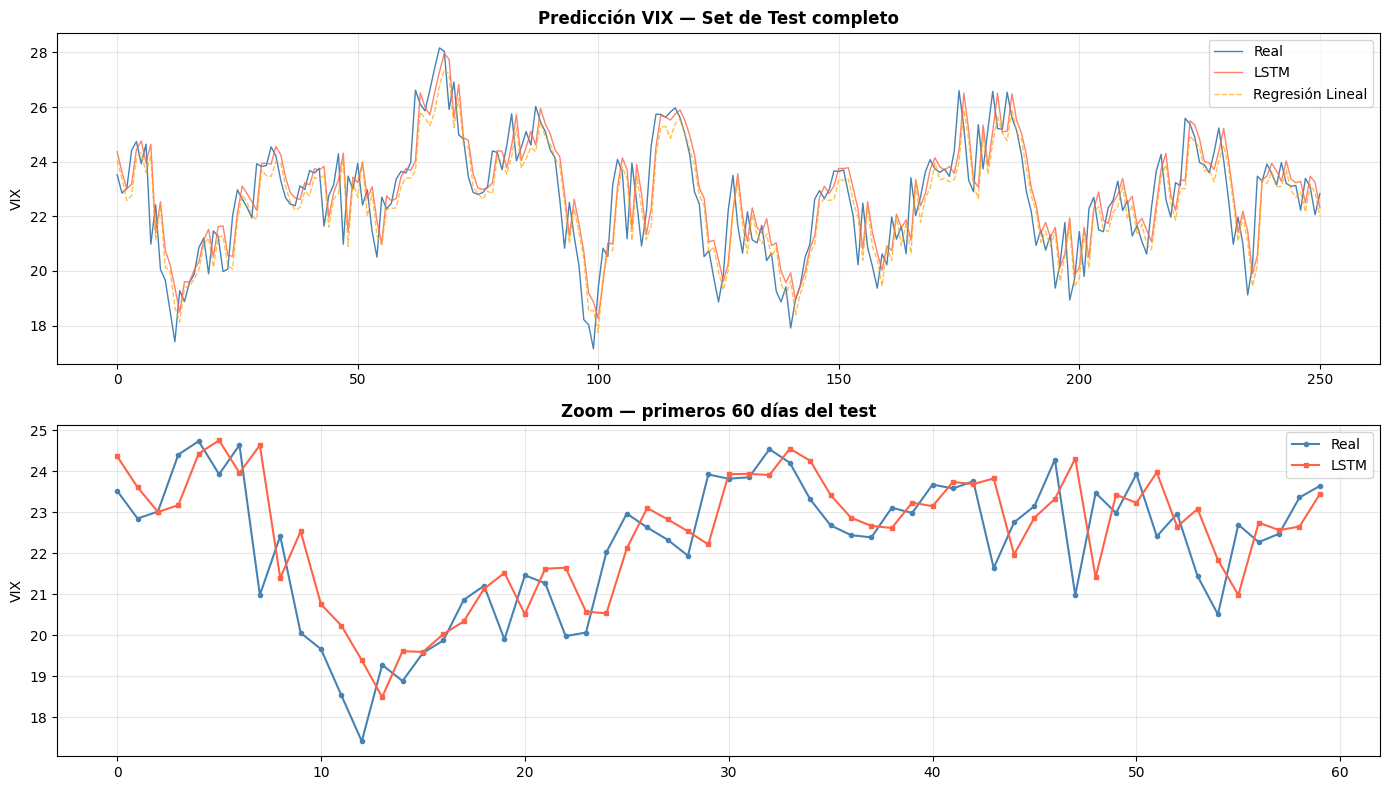

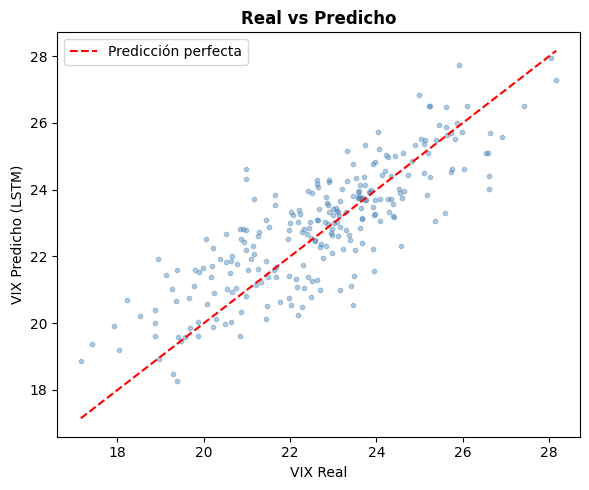

In [8]:
# Visualización: real vs predicho
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico completo
axes[0].plot(y_real, label='Real', color='steelblue', linewidth=1)
axes[0].plot(y_pred_lstm, label='LSTM', color='tomato', linewidth=1, alpha=0.8)
axes[0].plot(y_pred_lr, label='Regresión Lineal', color='orange', linewidth=1, alpha=0.7, linestyle='--')
axes[0].set_title('Predicción VIX — Set de Test completo', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('VIX')
axes[0].grid(alpha=0.3)

# Zoom primeros 60 días
zoom = 60
axes[1].plot(y_real[:zoom], label='Real', color='steelblue', linewidth=1.5, marker='o', markersize=3)
axes[1].plot(y_pred_lstm[:zoom], label='LSTM', color='tomato', linewidth=1.5, marker='s', markersize=3)
axes[1].set_title(f'Zoom — primeros {zoom} días del test', fontweight='bold')
axes[1].legend()
axes[1].set_ylabel('VIX')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter: real vs predicho
plt.figure(figsize=(6, 5))
plt.scatter(y_real, y_pred_lstm, alpha=0.4, color='steelblue', s=10)
lims = [min(y_real.min(), y_pred_lstm.min()), max(y_real.max(), y_pred_lstm.max())]
plt.plot(lims, lims, 'r--', label='Predicción perfecta')
plt.xlabel('VIX Real')
plt.ylabel('VIX Predicho (LSTM)')
plt.title('Real vs Predicho', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**📌 Lectura del gráfico:**
- La curva LSTM (rojo) sigue de cerca la serie real (azul) en tendencia general, pero **suaviza los picos** — característico de modelos que minimizan MSE promediando incertidumbre
- En el zoom de los primeros 60 días el tracking es bastante preciso; las mayores desviaciones aparecen en movimientos bruscos
- El scatter real vs predicho muestra los puntos alineados cerca de la diagonal, con dispersión simétrica — sin sesgo sistemático (no sobreestima ni subestima consistentemente)
- La nube se ensancha en valores extremos (VIX alto o bajo): el modelo predice mejor el centro que los extremos

## 8. Conclusiones

### ¿Es el VIX predecible o un random walk?

Un **random walk puro** implica que los cambios son completamente aleatorios: `VIX(t) = VIX(t-1) + ε`. En ese caso la autocorrelación sería ≈0 para todos los lags y ningún modelo superaría a la persistencia.

**Resultados obtenidos:**

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| 🧠 LSTM | 0.932 | 1.175 | **+0.674** |
| 📈 Regresión Lineal | 0.931 | 1.176 | +0.673 |
| 📌 Persistencia | 0.965 | 1.205 | +0.658 |

### ¿Qué nos dice un R² = 0.67?

R² = 0.67 significa que los modelos explican el **67% de la varianza** del VIX en el test set. Esto es **moderadamente alto**, no bajo. La serie **no es un random walk**: tiene estructura temporal aprovechable. Un random walk tendría R² ≈ 0 para cualquier modelo no trivial.

### El hallazgo más importante: LSTM ≈ Regresión Lineal

La diferencia entre LSTM y Regresión Lineal es prácticamente nula (MAE: 0.932 vs 0.931; R²: 0.674 vs 0.673). Esto tiene una interpretación clara: **la estructura predecible de esta serie es predominantemente lineal**. La LSTM, con su capacidad de capturar relaciones no lineales complejas, no aporta valor adicional sobre un modelo lineal simple. Esto puede ocurrir cuando:
- La serie está dominada por autocorrelación de primer orden (hoy ≈ ayer)
- No hay patrones no lineales significativos en el rango temporal analizado
- El dataset simulado es más suave que el VIX real (std = 2.34 sobre media 21.54, sin eventos extremos)

### Limitaciones del análisis
- El VIX simulado carece de los picos extremos del VIX real (COVID: ~85, GFC: ~80). En series reales, la LSTM sí suele superar modelos lineales precisamente en esos regímenes de alta volatilidad
- Con ~1.300 datos, la LSTM de 50.497 parámetros está en el límite: puede estar sub-entrenada
- No se incluyó early stopping ni regularización avanzada

### Conclusión

El VIX simulado muestra **predictibilidad real y significativa** (R² = 0.67), descartando la hipótesis de random walk puro. Sin embargo, esa predictibilidad es de naturaleza **lineal**: la Regresión Lineal alcanza el mismo rendimiento que la LSTM con una fracción de la complejidad. En este dataset, el modelo más sencillo gana en simplicidad sin ceder precisión — un recordatorio del principio de **parsimonia** en Machine Learning.